# Multi-View Robot Self-Modeling Dataset Generation

## Overview

This notebook generates synchronized dual-camera images in PyBullet and saves end-effector XYZ targets for NeuroKin training. It uses Lorenz trajectories to drive smooth joint motion, then captures two orthogonal camera views per step.

In [1]:
!pip -q install pybullet opencv-python
import os
import time
import numpy as np
import pybullet as p
import pybullet_data
import cv2
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Configuration

Update `ROOT_DIR` if your repository lives elsewhere. Camera parameters and dataset size are centralized here for easy tuning.

In [3]:
if IN_COLAB:
    drive.mount('/content/drive')
    ROOT_DIR = '/content/drive/MyDrive/robot_self_modelling'
else:
    ROOT_DIR = os.path.abspath('.')

URDF_PATH = os.path.join(ROOT_DIR, 'RobotArmURDF', '4dof_1st', 'urdf', '4dof_1st.urdf')
SAVE_DIR = os.path.join(ROOT_DIR, 'data', 'sim_data_multi_view')
os.makedirs(SAVE_DIR, exist_ok=True)

IMAGE_W = 100
IMAGE_H = 100
CAM_FOV = 42
CAM_NEAR = 0.1
CAM_FAR = 100.0
CAM_DIST = 1.0
SIM_STEPS = 50

TRAIN_SAMPLES = 1600
TEST_SAMPLES = 400

THRESHOLD = 240

if not os.path.exists(URDF_PATH):
    raise FileNotFoundError(f'URDF not found: {URDF_PATH}')

print(f'URDF_PATH: {URDF_PATH}')
print(f'SAVE_DIR: {SAVE_DIR}')

Mounted at /content/drive
URDF_PATH: /content/drive/MyDrive/robot_self_modelling/RobotArmURDF/4dof_1st/urdf/4dof_1st.urdf
SAVE_DIR: /content/drive/MyDrive/robot_self_modelling/data/sim_data_multi_view


## Camera and Image Helpers

View and projection matrices are explicitly defined here to make camera tuning straightforward.

In [4]:
def build_camera_matrices(camera_pos, target_pos, up_vec, fov, aspect, near, far):
    view = p.computeViewMatrix(
        cameraEyePosition=camera_pos,
        cameraTargetPosition=target_pos,
        cameraUpVector=up_vec
    )
    proj = p.computeProjectionMatrixFOV(
        fov=fov,
        aspect=aspect,
        nearVal=near,
        farVal=far
    )
    return view, proj

def preprocess_image(rgb, threshold=240):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    mask = (gray < threshold).astype(np.uint8) * 255
    return mask

## Dual-Camera PyBullet Environment

Two fixed cameras are used to capture complementary views at each step, and the end-effector XYZ is extracted from the final link.

In [5]:
class DualCameraEnv:
    def __init__(self, urdf_path, width, height, cam1_cfg, cam2_cfg, fov, near, far, sim_steps=50):
        self.urdf_path = urdf_path
        self.width = width
        self.height = height
        self.aspect = width / float(height)
        self.fov = fov
        self.near = near
        self.far = far
        self.sim_steps = sim_steps
        self.num_motor = 4
        self.max_angle_rad = np.pi / 2

        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())

        self.cam1_view, self.cam1_proj = build_camera_matrices(
            cam1_cfg['pos'], cam1_cfg['target'], cam1_cfg['up'],
            self.fov, self.aspect, self.near, self.far
        )
        self.cam2_view, self.cam2_proj = build_camera_matrices(
            cam2_cfg['pos'], cam2_cfg['target'], cam2_cfg['up'],
            self.fov, self.aspect, self.near, self.far
        )

        self.reset()

    def reset(self):
        p.resetSimulation()
        p.setGravity(0, 0, -9.8)

        plane_visual_shape_id = p.createVisualShape(
            shapeType=p.GEOM_PLANE,
            rgbaColor=[1, 1, 1, 1],
            planeNormal=[0, 0, 1]
        )
        p.createMultiBody(
            baseMass=0,
            baseVisualShapeIndex=plane_visual_shape_id,
            basePosition=[0, 0, -0.109]
        )

        try:
            self.robot_id = p.loadURDF(
                self.urdf_path,
                [0, 0, -0.108],
                p.getQuaternionFromEuler([0, 0, -np.pi / 2]),
                useFixedBase=1
            )
        except Exception as exc:
            raise RuntimeError(f'URDF load failed: {exc}') from exc

        for i in range(p.getNumJoints(self.robot_id)):
            p.resetJointState(self.robot_id, i, 0)

        self.ee_link_index = p.getNumJoints(self.robot_id) - 1

    def _capture(self, view, proj):
        img_arr = p.getCameraImage(
            self.width, self.height, view, proj,
            renderer=p.ER_TINY_RENDERER,
            shadow=0
        )
        rgb = np.reshape(img_arr[2], (self.height, self.width, 4))[:, :, :3]
        return rgb.astype(np.uint8)

    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        target_angles = action * self.max_angle_rad

        for i in range(self.num_motor):
            p.setJointMotorControl2(
                bodyUniqueId=self.robot_id,
                jointIndex=i,
                controlMode=p.POSITION_CONTROL,
                targetPosition=target_angles[i],
                force=100
            )

        for _ in range(self.sim_steps):
            p.stepSimulation()

        rgb1 = self._capture(self.cam1_view, self.cam1_proj)
        rgb2 = self._capture(self.cam2_view, self.cam2_proj)

        joint_angles = []
        for i in range(self.num_motor):
            state = p.getJointState(self.robot_id, i)
            joint_angles.append(np.degrees(state[0]))

        ee_pos = p.getLinkState(
            self.robot_id,
            self.ee_link_index,
            computeForwardKinematics=True
        )[0]

        return np.array(joint_angles, dtype=np.float32), rgb1, rgb2, np.array(ee_pos, dtype=np.float32)

    def close(self):
        p.disconnect()

## Lorenz Trajectory Generation

The Lorenz attractor provides smooth, chaotic trajectories that explore the workspace without sudden jumps.

In [6]:
def lorenz_system(state, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

def generate_lorenz_trajectory(num_steps, dt=0.01, scale=0.02, init_state=None):
    if init_state is None:
        state = np.array([1.0, 1.0, 1.0], dtype=np.float32)
    else:
        state = np.array(init_state, dtype=np.float32)
    trajectory = []
    for _ in range(num_steps):
        k1 = lorenz_system(state)
        k2 = lorenz_system(state + dt / 2 * k1)
        k3 = lorenz_system(state + dt / 2 * k2)
        k4 = lorenz_system(state + dt * k3)
        state = state + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        scaled = np.tanh(state * scale)
        trajectory.append(scaled)
    return np.array(trajectory)

def generate_lorenz_actions(num_steps, init_state1=None, init_state2=None):
    if init_state2 is None:
        init_state2 = init_state1
    traj1 = generate_lorenz_trajectory(num_steps, dt=0.01, scale=0.025, init_state=init_state1)
    traj2 = generate_lorenz_trajectory(num_steps, dt=0.012, scale=0.022, init_state=init_state2)
    actions = np.stack(
        [traj1[:, 0], traj1[:, 1], traj2[:, 0], traj2[:, 2]],
        axis=1
    )
    return np.clip(actions, -1, 1)

## Dataset Generation

Images are converted to grayscale and thresholded to binary masks for compact storage.

In [7]:
def generate_dataset(env, actions, threshold=240, log_every=200):
    num_samples = actions.shape[0]
    images_cam1 = np.zeros((num_samples, env.height, env.width), dtype=np.uint8)
    images_cam2 = np.zeros((num_samples, env.height, env.width), dtype=np.uint8)
    ee_xyz = np.zeros((num_samples, 3), dtype=np.float32)
    joint_angles = np.zeros((num_samples, env.num_motor), dtype=np.float32)

    start_time = time.time()
    for i in range(num_samples):
        joints, rgb1, rgb2, ee_pos = env.step(actions[i])
        images_cam1[i] = preprocess_image(rgb1, threshold)
        images_cam2[i] = preprocess_image(rgb2, threshold)
        ee_xyz[i] = ee_pos
        joint_angles[i] = joints

        if log_every and i % log_every == 0 and i > 0:
            print(f'Sample {i}/{num_samples} | ee_xyz: {ee_xyz[i].round(3)}')

    elapsed = time.time() - start_time
    print(f'Generation done in {elapsed:.1f}s ({num_samples / max(elapsed, 1e-6):.1f} samples/sec)')
    return images_cam1, images_cam2, ee_xyz, joint_angles

## Image Processing Sanity Check

Before running full generation, we verify the image preprocessing pipeline (RGB -> Grayscale -> Binary Mask) on a single sample.

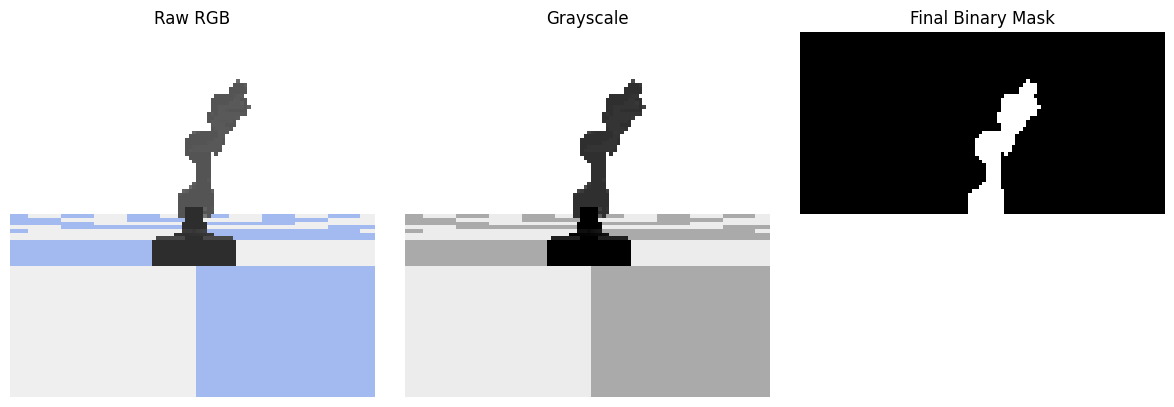

In [8]:
cam1_cfg = {'pos': [CAM_DIST, 0, 0], 'target': [0, 0, 0], 'up': [0, 0, 1]}
cam2_cfg = {'pos': [0, CAM_DIST, 0], 'target': [0, 0, 0], 'up': [0, 0, 1]}

temp_env = DualCameraEnv(URDF_PATH, IMAGE_W, IMAGE_H, cam1_cfg, cam2_cfg, CAM_FOV, CAM_NEAR, CAM_FAR)
_, rgb1, _, _ = temp_env.step([0.2, -0.1, 0.3, 0.0])
gray = cv2.cvtColor(rgb1, cv2.COLOR_RGB2GRAY)
mask = preprocess_image(rgb1, THRESHOLD)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rgb1)
axes[0].set_title('Raw RGB')
axes[0].axis('off')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')
axes[2].imshow(mask, cmap='gray')
axes[2].set_title('Final Binary Mask')
axes[2].axis('off')
plt.tight_layout()
plt.show()
temp_env.close()

## Lorenz Trajectory Visualization

We plot the 4 joint angles over time to verify the smooth, chaotic nature of the Lorenz-driven dataset.

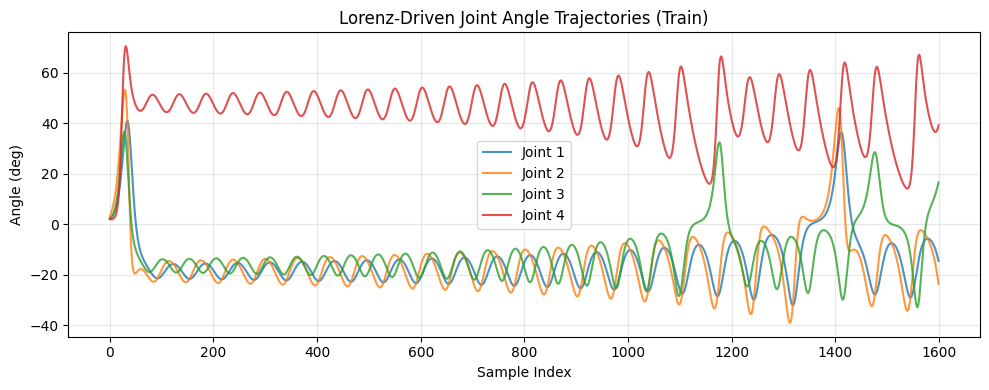

In [9]:
train_actions = generate_lorenz_actions(TRAIN_SAMPLES)
angles_deg = train_actions * 90.0
fig, ax = plt.subplots(figsize=(10, 4))
for j in range(4):
    ax.plot(angles_deg[:, j], label=f'Joint {j+1}', alpha=0.8)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Angle (deg)')
ax.set_title('Lorenz-Driven Joint Angle Trajectories (Train)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Run Generation and Save

This cell generates the dataset and saves full and split files.

In [10]:
cam1_cfg = {
    'pos': [CAM_DIST, 0, 0],
    'target': [0, 0, 0],
    'up': [0, 0, 1],
}
cam2_cfg = {
    'pos': [0, CAM_DIST, 0],
    'target': [0, 0, 0],
    'up': [0, 0, 1],
}

env = DualCameraEnv(
    URDF_PATH, IMAGE_W, IMAGE_H,
    cam1_cfg, cam2_cfg,
    CAM_FOV, CAM_NEAR, CAM_FAR,
    sim_steps=SIM_STEPS
)

train_actions = generate_lorenz_actions(TRAIN_SAMPLES)
train_images_cam1, train_images_cam2, train_ee_xyz, train_joint_angles = generate_dataset(
    env, train_actions, threshold=THRESHOLD
 )

env.reset()
test_init = np.array([-1.0, 0.5, 2.0], dtype=np.float32)
test_actions = generate_lorenz_actions(
    TEST_SAMPLES,
    init_state1=test_init,
    init_state2=test_init + np.array([0.3, -0.2, 0.1], dtype=np.float32)
 )
test_images_cam1, test_images_cam2, test_ee_xyz, test_joint_angles = generate_dataset(
    env, test_actions, threshold=THRESHOLD
 )

print('Train images_cam1:', train_images_cam1.shape)
print('Train images_cam2:', train_images_cam2.shape)
print('Train ee_xyz:', train_ee_xyz.shape)
print('Train joint_angles:', train_joint_angles.shape)
print('Test images_cam1:', test_images_cam1.shape)
print('Test images_cam2:', test_images_cam2.shape)
print('Test ee_xyz:', test_ee_xyz.shape)
print('Test joint_angles:', test_joint_angles.shape)

train_path = os.path.join(SAVE_DIR, 'mv_robo1_train.npz')
test_path = os.path.join(SAVE_DIR, 'mv_robo1_test.npz')

np.savez_compressed(
    train_path,
    images_cam1=train_images_cam1,
    images_cam2=train_images_cam2,
    ee_xyz=train_ee_xyz,
    joint_angles=train_joint_angles
 )
np.savez_compressed(
    test_path,
    images_cam1=test_images_cam1,
    images_cam2=test_images_cam2,
    ee_xyz=test_ee_xyz,
    joint_angles=test_joint_angles
 )

env.close()

print('Saved:', train_path)
print('Saved:', test_path)

Sample 200/1600 | ee_xyz: [ 0.216 -0.071  0.044]
Sample 400/1600 | ee_xyz: [ 0.209 -0.085  0.032]
Sample 600/1600 | ee_xyz: [ 0.2   -0.076  0.049]
Sample 800/1600 | ee_xyz: [ 0.205 -0.055  0.076]
Sample 1000/1600 | ee_xyz: [ 0.213 -0.04   0.114]
Sample 1200/1600 | ee_xyz: [ 0.207 -0.026  0.132]
Sample 1400/1600 | ee_xyz: [0.083 0.032 0.216]
Generation done in 69.0s (23.2 samples/sec)
Sample 200/400 | ee_xyz: [0.1   0.028 0.256]
Generation done in 17.8s (22.4 samples/sec)
Train images_cam1: (1600, 100, 100)
Train images_cam2: (1600, 100, 100)
Train ee_xyz: (1600, 3)
Train joint_angles: (1600, 4)
Test images_cam1: (400, 100, 100)
Test images_cam2: (400, 100, 100)
Test ee_xyz: (400, 3)
Test joint_angles: (400, 4)
Saved: /content/drive/MyDrive/robot_self_modelling/data/sim_data_multi_view/mv_robo1_train.npz
Saved: /content/drive/MyDrive/robot_self_modelling/data/sim_data_multi_view/mv_robo1_test.npz


## Visual Sanity Check

The grid below shows synchronized views from both cameras with their corresponding XYZ target.

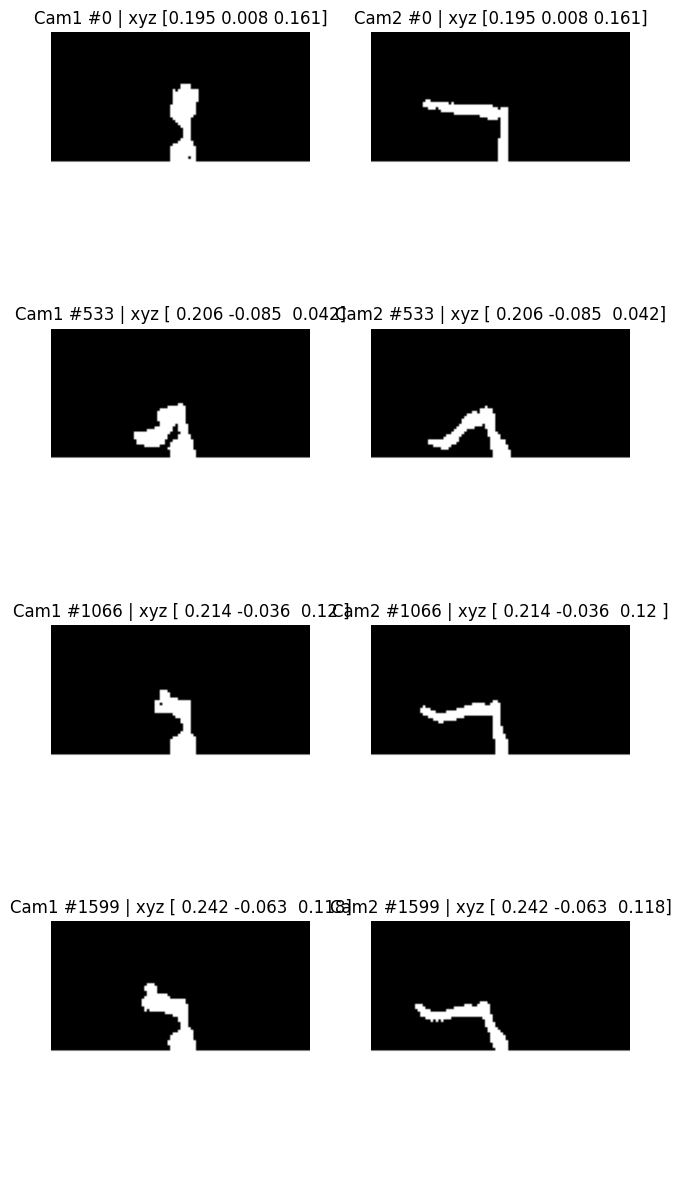

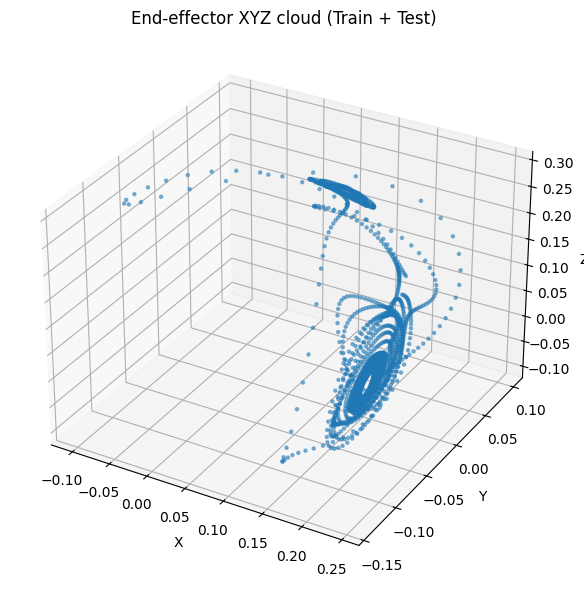

In [11]:
sample_idx = np.linspace(0, len(train_images_cam1) - 1, 4, dtype=int)
fig, axes = plt.subplots(len(sample_idx), 2, figsize=(7, 3 * len(sample_idx)))

for row, idx in enumerate(sample_idx):
    axes[row, 0].imshow(train_images_cam1[idx], cmap='gray')
    axes[row, 0].set_title(f'Cam1 #{idx} | xyz {train_ee_xyz[idx].round(3)}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(train_images_cam2[idx], cmap='gray')
    axes[row, 1].set_title(f'Cam2 #{idx} | xyz {train_ee_xyz[idx].round(3)}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

all_xyz = np.vstack([train_ee_xyz, test_ee_xyz])
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_xyz[:, 0], all_xyz[:, 1], all_xyz[:, 2], s=5, alpha=0.5)
ax.set_title('End-effector XYZ cloud (Train + Test)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

## Analysis

**Methodology (Lorenz trajectories).** The Lorenz system produces smooth, non-repeating trajectories from a continuous ODE, so joint commands evolve without discontinuities. This creates dense coverage of the configuration space while avoiding artificial jumps that can bias a learned model. In practice, the resulting dataset provides a consistent sampling of reachable poses with temporally smooth transitions.

**Stereo perception logic.** A single silhouette collapses depth along the viewing ray, so multiple 3D poses can map to the same 2D mask. Two orthogonal views constrain depth from complementary directions, enabling triangulation cues in the fused representation and reducing projection ambiguity when predicting $(x, y, z)$.

**Visual analysis.** The XYZ scatter forms a coherent, continuous reachability envelope with dense coverage across the workspace. From the plot, the cloud spans roughly $X \in [0.05, 0.25]$, $Y \in [-0.15, 0.10]$, and $Z \in [0.00, 0.30]$, with no obvious holes or directional bias. This indicates the Lorenz-driven exploration successfully populated a broad and balanced training volume for the end-effector state.